In [1]:
import tensorly as tl
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from moabb.paradigms import P300,LeftRightImagery, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = LeftRightImagery(resample=250)
dataset = BNCI2014004()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[2],
     return_epochs=True
)
session = meta['session'].unique()[0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns


/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 24 events (all good), 2 – 6 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 12
 'right_hand': 12>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 24 events (all good), 2 – 6 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 12
 'right_hand': 12>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 24 events (all good), 2 – 6 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 12
 'right_hand': 12>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 24 events (all good), 2 – 6 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 12
 'right_hand': 12>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/p

Adding metadata with 3 columns
288 matching events found
No baseline correction applied
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import stf_tensor
import numpy as np
from mne.decoding import Scaler

X = epochs.get_data()
X = Scaler(scalings='mean', with_mean=True).fit_transform(X)
X = stf_tensor(X, sfreq=epochs.info['sfreq'], normalize=True, log=True, n_freqs=8, bin_freq=8)
X = tl.tensor(X)
y = labels
X.shape

(144, 4, 8, 32)

/tmp/ipykernel_9744/1921624324.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x)


<Axes: ylabel='Density'>

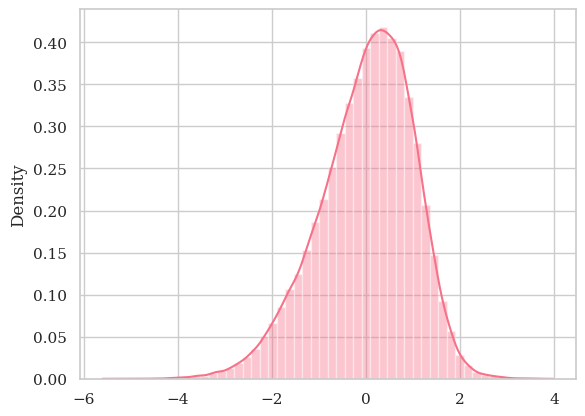

In [5]:
import seaborn as sns
x = X.flatten()
x = tl.to_numpy(x)
sns.distplot(x)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/5, random_state=2, stratify=y)

In [ ]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[[3,8,8]]*10,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore
%time bttda.fit(X_train,y_train)

Fitting block 1/10...


Forward model :   2%|▏         | 2/128 [00:00<00:02, 55.18it/s]


Fitting block 2/10...


Forward model :   2%|▏         | 2/128 [00:00<00:02, 53.83it/s]


Fitting block 3/10...


...

Forward model :   2%|▏         | 2/128 [00:00<00:02, 52.95it/s]


Fitting block 7/10...


Forward model :   2%|▏         | 2/128 [00:00<00:02, 56.75it/s]


Fitting block 8/10...


Backward HODA model rank=(3, 8, 8):  20%|██        | 26/128 [00:00<00:02, 38.52it/s]

In [ ]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

In [ ]:
import seaborn as sns
sns.lineplot(data=df, x='block', y='nmse')

In [ ]:
from hoda.hoda import forward_stats
info = []
for b in range(len(bttda.blocks_)):
    Xt_test = bttda.transform(X_test, blocks=bttda.blocks_[:b+1])
    X_rec_test = bttda.inv_transform(Xt_test, n_blocks=b+1)
    res = forward_stats(X_test, Xt_test, X_rec_test,y)
    res['block'] =b
    info.append(res)
info = pd.DataFrame(info)
sns.lineplot(data=info, x='block', y='nmse')
info

In [ ]:
from hoda.hoda import forward_stats
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

score_train = []
score_test = []
for b in range(len(bttda.blocks_)):
    Xt_train = tl.to_numpy(bttda.transform(X_train, blocks=bttda.blocks_[:b+1]))
    Xt_test = tl.to_numpy(bttda.transform(X_test, blocks=bttda.blocks_[:b+1]))
    clf = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
    clf.fit(Xt_train,y_train)
    score_train.append(accuracy_score(y_train, clf.predict(Xt_train)))
    score_test.append(accuracy_score(y_test, clf.predict(Xt_test)))
plt.plot(score_train)
plt.plot(score_test)

In [ ]:
Xt = bttda.transform(X)
Xt = tl.to_numpy(Xt)
corr = np.corrcoef(Xt, rowvar=False)
sns.heatmap(corr, center=0, cmap='vlag')